In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing  import StandardScaler

from pathlib import Path

In [2]:
path = Path.cwd().parent / 'data' / 'features' / 'features.csv'

df = pd.read_csv(path)
df

,pc_indicador_alfabetizacao,vl_proficiencia_media,vl_proficiencia_mediana,qt_alunos_avaliados,nu_serie,qtd_fam_pobreza,qtd_fam_baixa_renda,qtd_fam_ate_meio_sm,qtd_fam_renda_zero,taxa_atualizacao_geral_pct,...,pct_urbana,pct_rural,ano_2024,ds_rede_municipal,ds_rede_privada,nome_regiao_nordeste,nome_regiao_norte,nome_regiao_sudeste,nome_regiao_sul,uf_freq
0,0.4898,737.60,734.01,49,2,1032,307,1339,560,0.7553,...,0.7273,0.2727,0,1,0,0,0,1,0,0.175485
1,0.5718,747.21,751.72,376,2,1343,987,2330,487,0.7099,...,0.7714,0.2286,0,1,0,0,0,1,0,0.175485
2,0.8706,791.68,795.49,85,2,288,211,499,151,0.5359,...,1.0000,0.0000,0,1,0,0,0,1,0,0.175485
3,0.4440,736.56,737.62,268,2,3194,1618,4812,2053,0.7108,...,0.9737,0.0263,0,1,0,0,0,1,0,0.175485
4,0.3791,730.09,728.07,277,2,4477,924,5401,93,0.8051,...,0.3457,0.6543,0,1,0,0,0,1,0,0.175485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12412,0.6838,756.16,762.64,136,2,18823,5105,23928,147,0.8569,...,0.4174,0.5826,1,0,0,1,0,0,0,0.015624
12413,0.3681,718.33,716.52,144,2,6542,1654,8196,20,0.7740,...,0.8065,0.1935,0,0,0,1,0,0,0,0.015624
12414,0.7955,763.39,768.68,44,2,2857,1972,4829,851,0.6945,...,0.4247,0.5753,0,0,0,0,0,1,0,0.017315
12415,0.7143,762.45,764.47,35,2,1870,1454,3324,243,0.7392,...,0.5938,0.4062,0,0,0,0,0,1,0,0.017315


In [3]:
df["atingiu_meta"] = (
    df["pc_indicador_alfabetizacao"] >= 0.80
).astype(int)

In [4]:
X = df[['vl_proficiencia_media','vl_proficiencia_mediana','qt_alunos_avaliados','nu_serie','qtd_fam_pobreza','qtd_fam_baixa_renda','qtd_fam_ate_meio_sm','qtd_fam_renda_zero','taxa_atualizacao_geral_pct','taxa_atualizacao_ate_meio_sm_pct','qtd_escolas','pct_urbana','pct_rural','ano_2024','ds_rede_municipal','ds_rede_privada','nome_regiao_nordeste','nome_regiao_norte','nome_regiao_sudeste','nome_regiao_sul','uf_freq']] 
y = df['atingiu_meta']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Treino:',X_train.shape)
print('Teste:', X_test.shape)


Treino: (9933, 21)
Teste: (2484, 21)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled,y_train)

pred_log = log_model.predict(X_test_scaled)

In [8]:
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print(y_proba[:10])

[9.99996025e-01 1.06480586e-04 6.43145983e-03 2.13926869e-03
 1.46218477e-02 1.20222045e-01 9.75583036e-01 1.50262094e-02
 5.64968014e-07 1.05815813e-07]


In [9]:
acc_log = accuracy_score(y_test, pred_log)

print('Acurácia:', acc_log)

Acurácia: 0.927536231884058


In [10]:
print(df['atingiu_meta'].value_counts())

print("\nProporção:")
print(df['atingiu_meta'].value_counts(normalize=True))

atingiu_meta
0    9873
1    2544
Name: count, dtype: int64

Proporção:
atingiu_meta
0    0.79512
1    0.20488
Name: proportion, dtype: float64


In [11]:
cm = confusion_matrix(y_test, pred_log)

print(cm)

[[1917   73]
 [ 107  387]]


In [12]:
precision = precision_score(y_test, pred_log)

print("Precision:", precision)

Precision: 0.841304347826087


In [13]:
recall = recall_score(y_test, pred_log)

print("Recall:", recall)

Recall: 0.7834008097165992


In [14]:
f1 = f1_score(y_test, pred_log)

print("F1-Score:", f1)

F1-Score: 0.8113207547169812


In [15]:
print(classification_report(y_test, pred_log))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1990
           1       0.84      0.78      0.81       494

    accuracy                           0.93      2484
   macro avg       0.89      0.87      0.88      2484
weighted avg       0.93      0.93      0.93      2484



In [16]:
auc = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", auc)

ROC-AUC: 0.9752171790124713


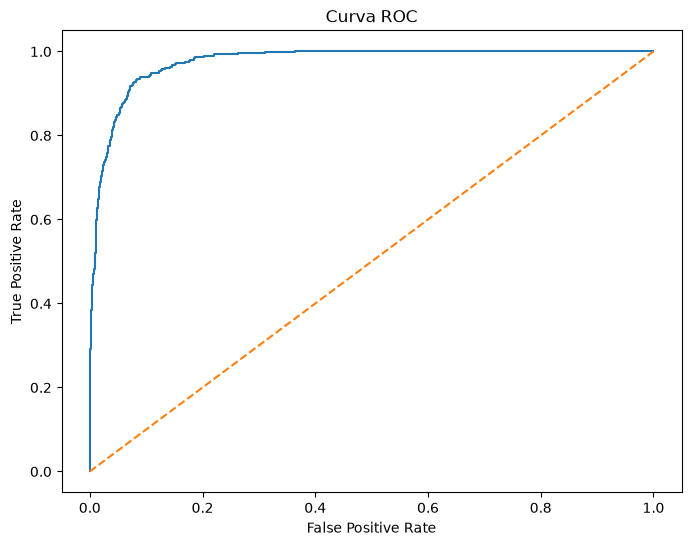

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.show()

### Feature Importance

In [18]:
log_model.fit(X_train_scaled, y_train)

coeficientes = log_model.coef_[0]

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': coeficientes
})

feature_importance

,feature,coeficiente
0,vl_proficiencia_media,7.000268
1,vl_proficiencia_mediana,-1.045162
2,qt_alunos_avaliados,-0.744693
3,nu_serie,0.000000
4,qtd_fam_pobreza,-0.176499
5,qtd_fam_baixa_renda,0.388922
6,qtd_fam_ate_meio_sm,-0.046344
7,qtd_fam_renda_zero,0.164978
8,taxa_atualizacao_geral_pct,0.138754
9,taxa_atualizacao_ate_meio_sm_pct,0.085085


In [19]:
feature_importance['importance'] = (
    feature_importance['coeficiente'].abs()
)

In [20]:
feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

feature_importance

,feature,coeficiente,importance
0,vl_proficiencia_media,7.000268,7.000268
1,vl_proficiencia_mediana,-1.045162,1.045162
16,nome_regiao_nordeste,-0.933455,0.933455
2,qt_alunos_avaliados,-0.744693,0.744693
18,nome_regiao_sudeste,-0.423419,0.423419
5,qtd_fam_baixa_renda,0.388922,0.388922
19,nome_regiao_sul,0.275585,0.275585
20,uf_freq,0.204129,0.204129
4,qtd_fam_pobreza,-0.176499,0.176499
13,ano_2024,0.169830,0.169830


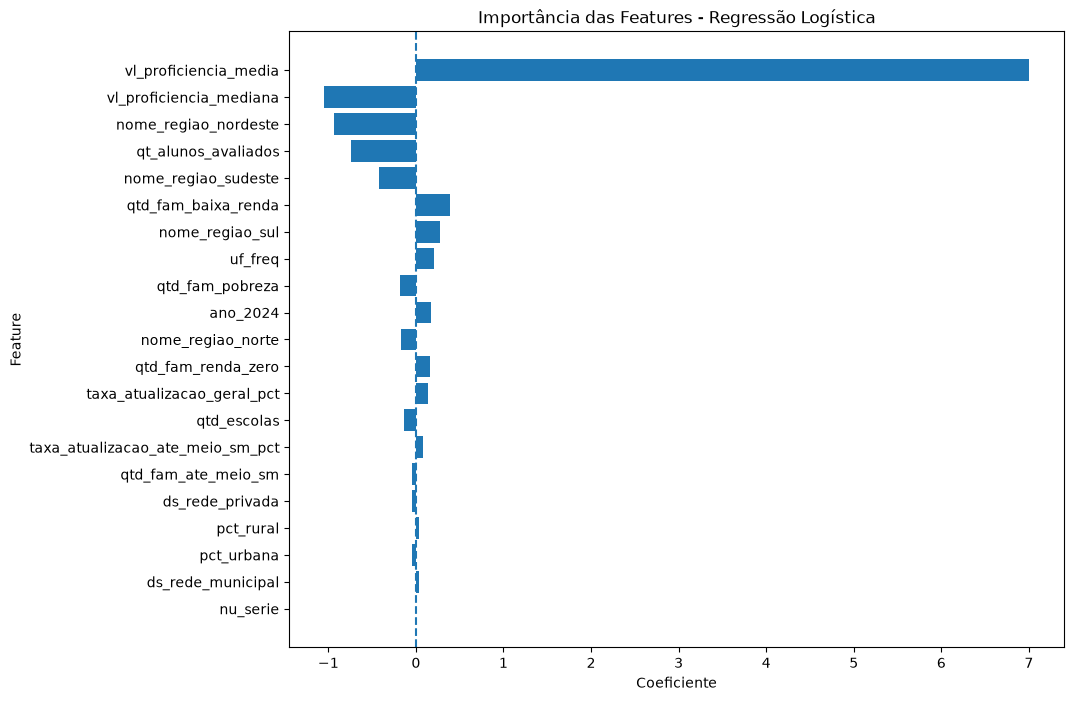

In [21]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['feature'],
    feature_importance['coeficiente']
)

plt.xlabel('Coeficiente')
plt.ylabel('Feature')
plt.title('Importância das Features - Regressão Logística')

plt.axvline(0, linestyle='--')

plt.gca().invert_yaxis()

plt.show()

In [22]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coeficiente': log_model.coef_[0]
})

feature_importance['importance'] = (
    feature_importance['coeficiente'].abs()
)

feature_importance['odds_ratio'] = (
    np.exp(feature_importance['coeficiente'])
)

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

feature_importance

,feature,coeficiente,importance,odds_ratio
0,vl_proficiencia_media,7.000268,7.000268,1096.926800
1,vl_proficiencia_mediana,-1.045162,1.045162,0.351635
16,nome_regiao_nordeste,-0.933455,0.933455,0.393193
2,qt_alunos_avaliados,-0.744693,0.744693,0.474880
18,nome_regiao_sudeste,-0.423419,0.423419,0.654804
5,qtd_fam_baixa_renda,0.388922,0.388922,1.475389
19,nome_regiao_sul,0.275585,0.275585,1.317302
20,uf_freq,0.204129,0.204129,1.226456
4,qtd_fam_pobreza,-0.176499,0.176499,0.838199
13,ano_2024,0.169830,0.169830,1.185103
